# ggh4x — Statistics

Python port of the ggh4x **Statistics** vignette on `ggplot2_py`: theoretical density fits, rolling-kernel trends, signed differences, x/y summary functions, and run-length encoding. Data here is generated in Python for a self-contained tutorial (illustrative, not seed-identical to R).

In [1]:
import numpy as np, pandas as pd
np.random.seed(0)
from ggplot2_py import ggplot, aes, geom_point
from ggh4x import (stat_theodensity, stat_rollingkernel, stat_difference,
                   stat_funxy, stat_centroid, stat_midpoint, stat_rle)
from ggh4x._datasets import load_faithful, mpg, economics

# faithful, split into High/Low eruption groups
faithful = load_faithful(); faithful["group"] = np.where(faithful["eruptions"] > 3, "High", "Low")
# Student-t and F samples (two groups each) for the awkward-distribution fits
tdf = pd.DataFrame({"x": np.concatenate([np.random.standard_t(2, 1000), np.random.standard_t(4, 1000)]),
                    "group": np.repeat(["A", "B"], 1000)})
fdf = pd.DataFrame({"x": np.concatenate([np.random.f(4, 8, 1000), np.random.f(8, 16, 1000)]),
                    "group": np.repeat(["A", "B"], 1000)})
# discrete counts (Poisson + negative-binomial); nbinom(size=2, mu=5) -> p = 2/7
ndf = pd.DataFrame({"x": np.concatenate([np.random.poisson(5, 1000),
                                         np.random.negative_binomial(2, 2/7, 1000)]).astype(int),
                    "group": np.repeat(["A", "B"], 1000)})
cdf = pd.DataFrame({"x": np.random.normal(10, 1, 1000) + np.random.standard_cauchy(1000) * 0.3})
dummy = pd.DataFrame({"x": [1, 2, 3, 4], "ymin": [0, 1, 2, 2.5], "ymax": [2.5, 2, 1, 0.5]})
rdf = pd.DataFrame({"x": np.linspace(0, 10, 100)}); rdf["y"] = np.cos(rdf["x"])
rdf["lab"] = pd.cut(rdf["y"], 3).astype(str)

## Theoretical densities — `stat_theodensity`

Fits a distribution by maximum likelihood and draws its density/PMF, per group. Continuous example (gamma fit on the two eruption groups):

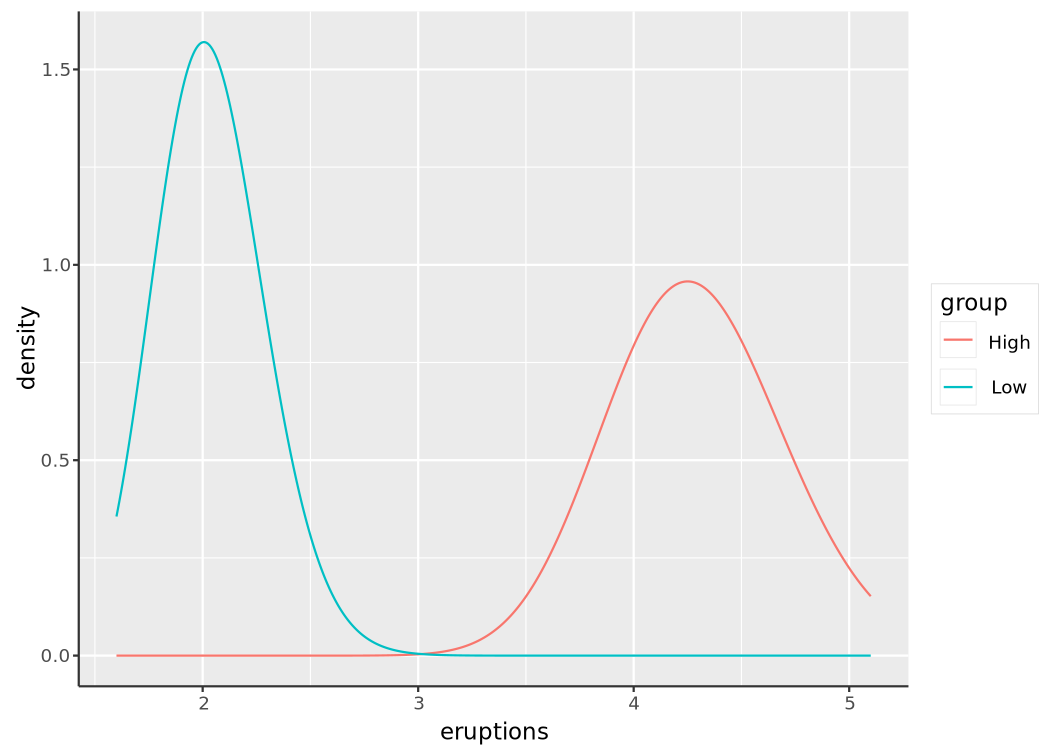

In [2]:
ggplot(faithful, aes(x="eruptions", color="group")) + stat_theodensity(distri="gamma")

Distributions without natural starting values (Student-t, F) take a `start_arg`:

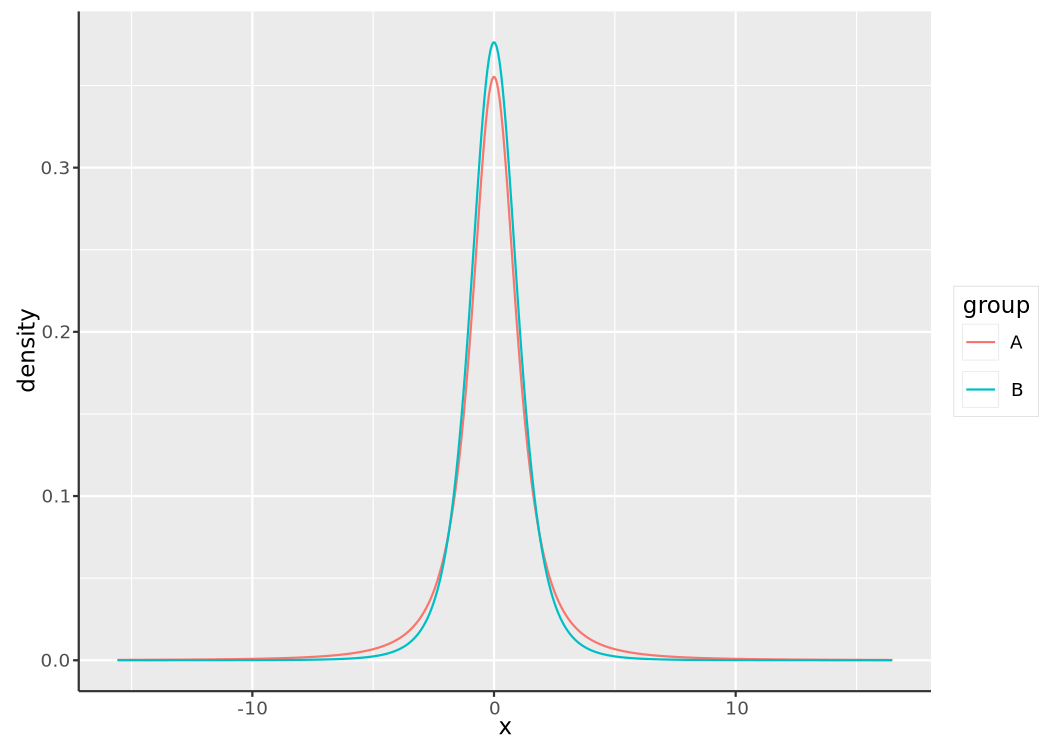

In [3]:
ggplot(tdf, aes(x="x", color="group")) + stat_theodensity(distri="t", start_arg={"df": 3})

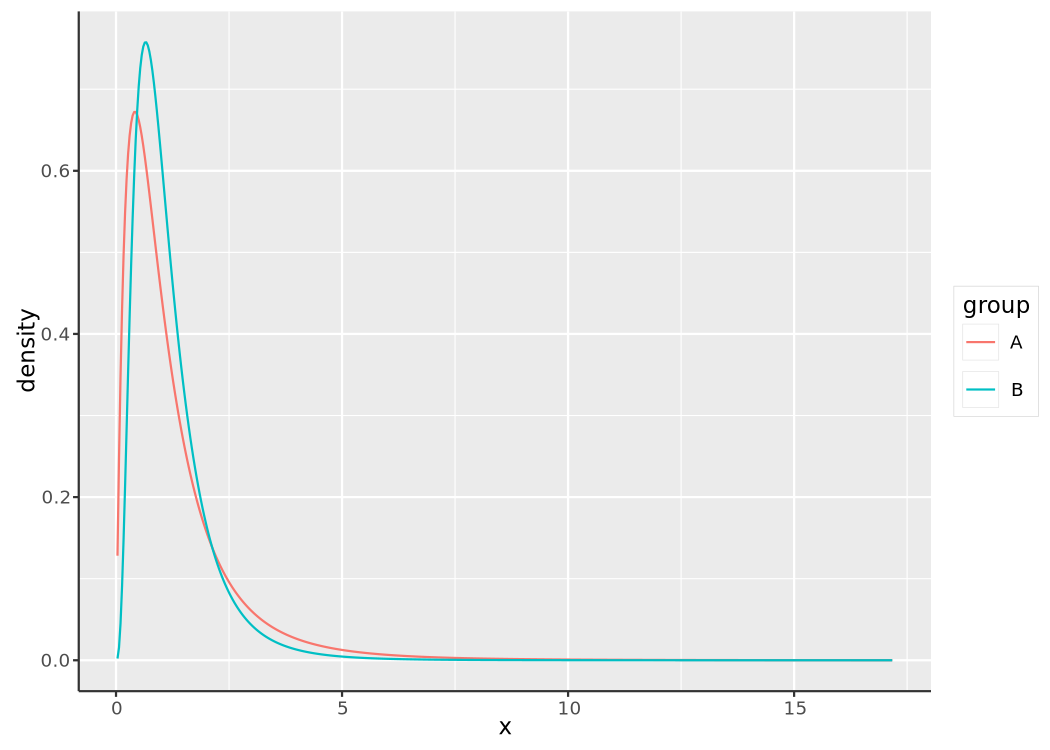

In [4]:
ggplot(fdf, aes(x="x", color="group")) + stat_theodensity(distri="f", start_arg={"df1": 3, "df2": 3})

Discrete distributions need integer input; here a negative-binomial fit (shown as points, since lines imply a continuity discrete masses don't have):

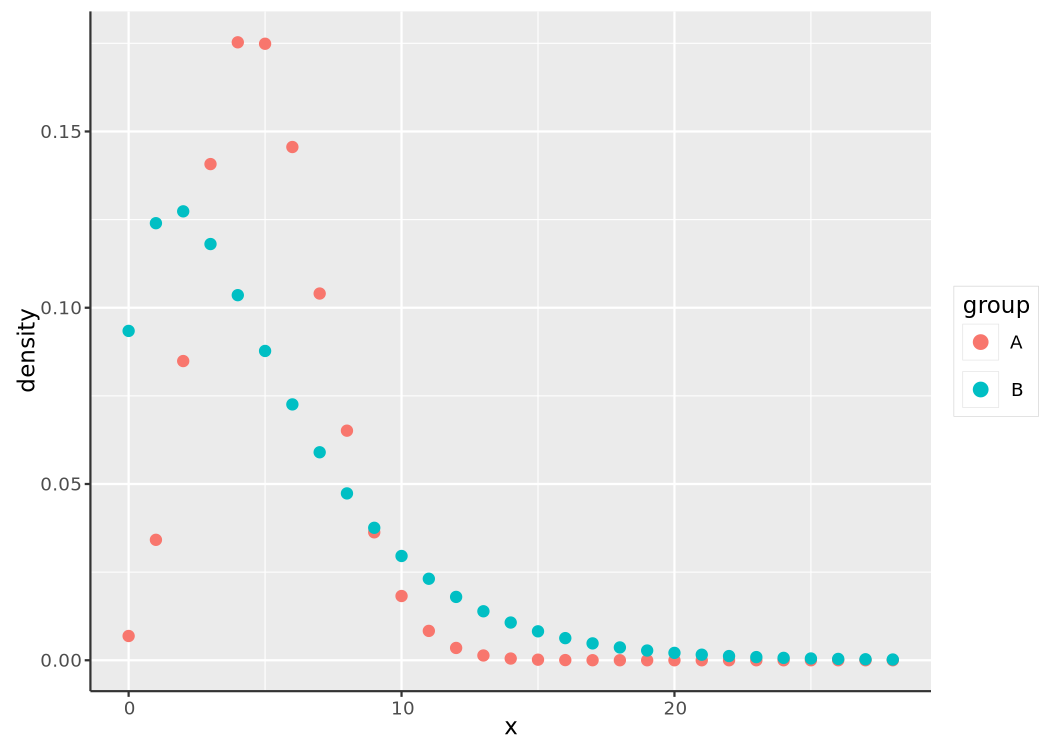

In [5]:
ggplot(ndf, aes(x="x", color="group")) + stat_theodensity(distri="nbinom", geom="point")

Comparing two candidate fits to the same data (normal vs Cauchy):

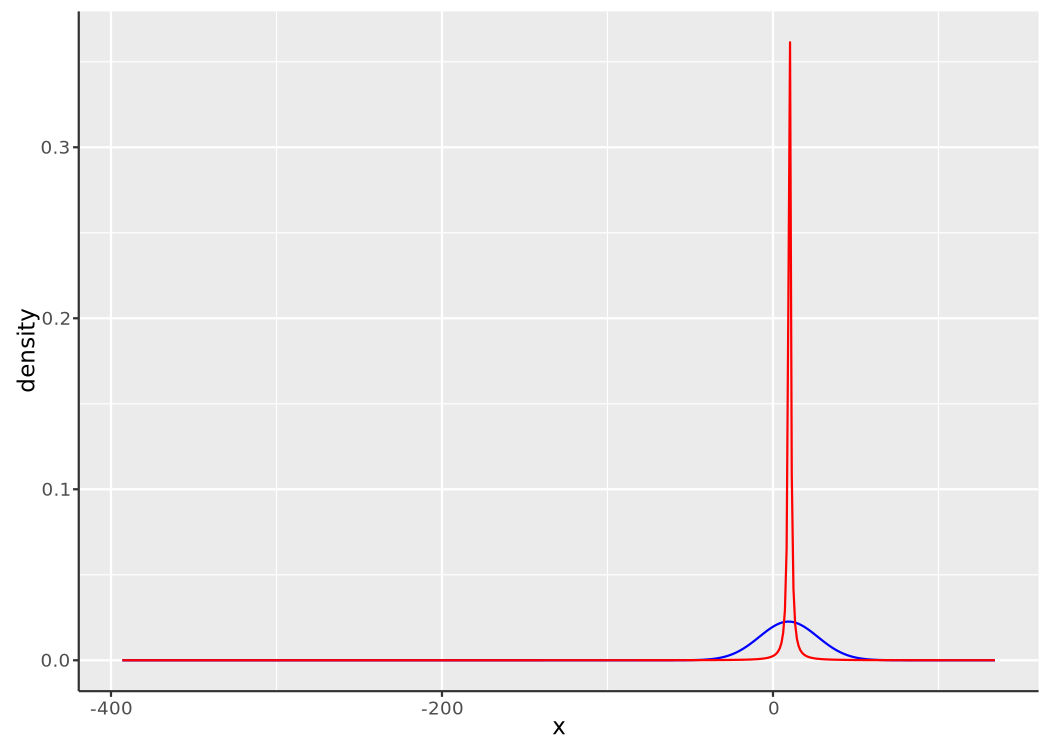

In [6]:
ggplot(cdf, aes(x="x")) + stat_theodensity(distri="norm", color="blue") + stat_theodensity(distri="cauchy", color="red")

## Rolling kernels — `stat_rollingkernel`

A model-free trend line: a kernel weights nearby points by x-distance and takes a weighted mean. Gaussian kernel on `mpg`:

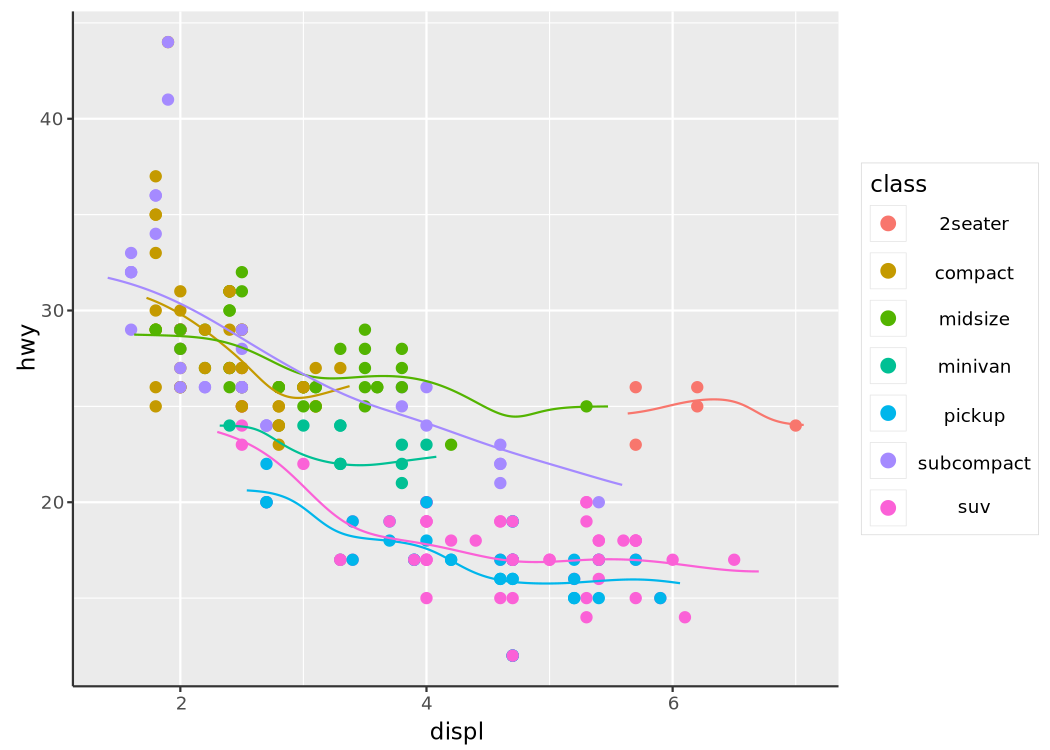

In [7]:
ggplot(mpg, aes(x="displ", y="hwy", color="class")) + geom_point() + stat_rollingkernel()

A uniform (`"mean"`) kernel gives a blockier rolling mean:

/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/geom.py:561: UserWarning: Removed 13 rows containing missing values (geom_line).
  return remove_missing(data, vars=check_vars, na_rm=na_rm, name=snake_class(self))


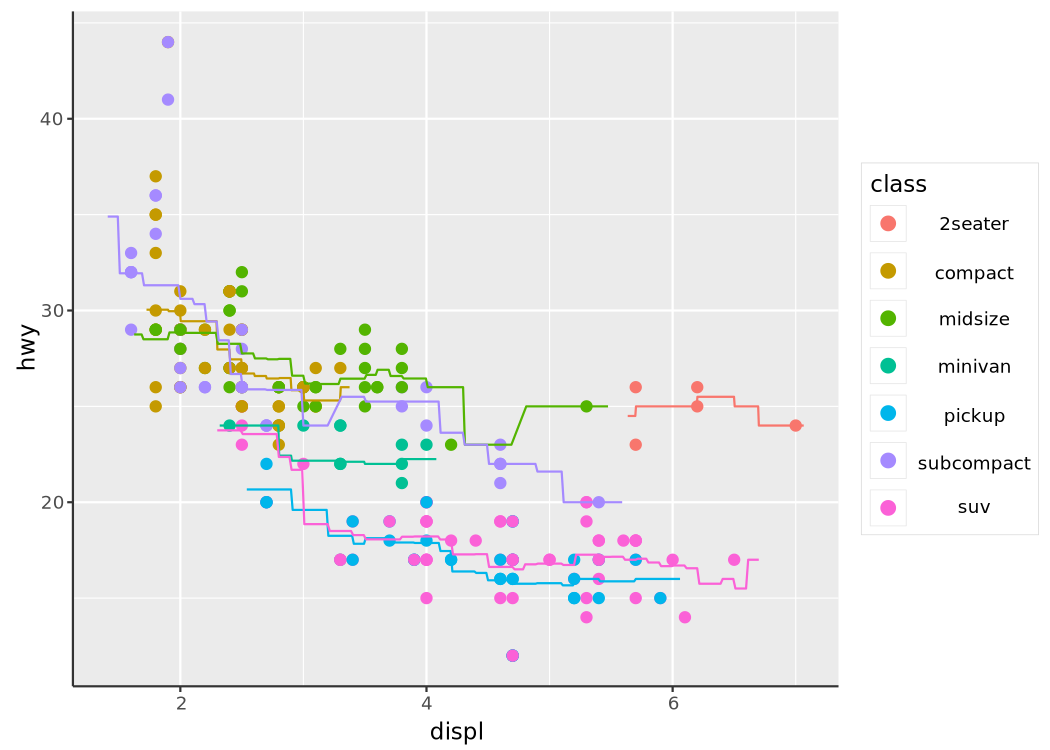

In [8]:
ggplot(mpg, aes(x="displ", y="hwy", color="class")) + geom_point() + stat_rollingkernel(kernel="mean", bw=1)

## Signed difference — `stat_difference`

Run-length re-groups a ribbon by which series is larger and interpolates the crossings. On the `economics` series:

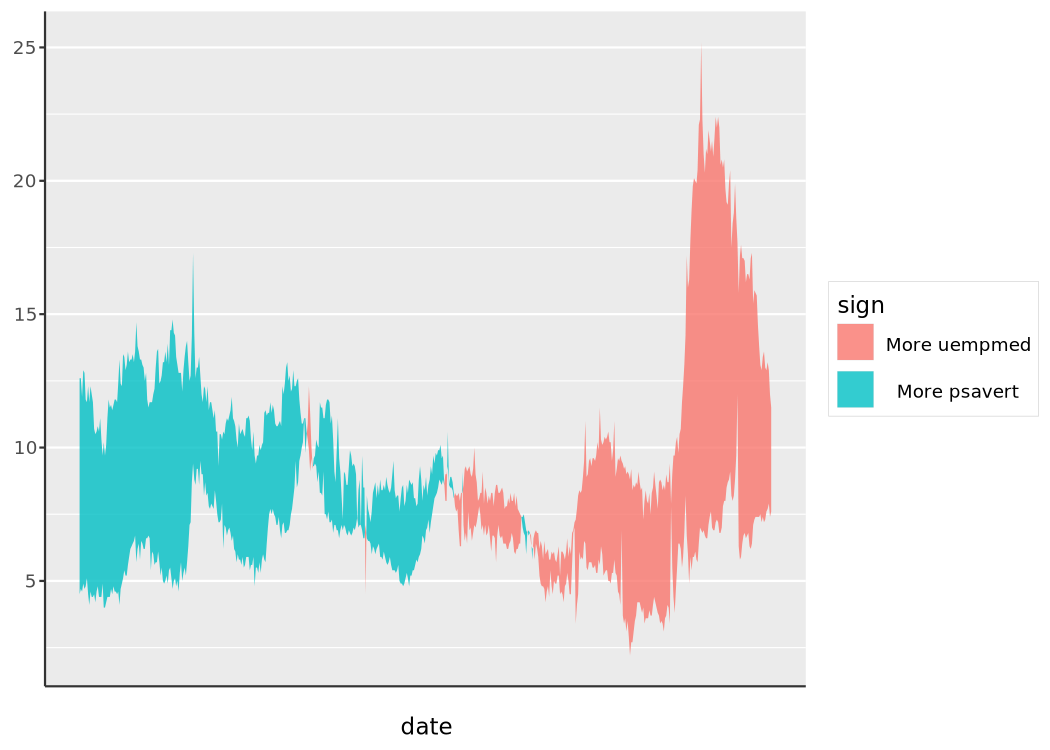

In [9]:
ggplot(economics, aes(x="date")) + stat_difference(aes(ymin="psavert", ymax="uempmed"), levels=["More uempmed", "More psavert"], alpha=0.8)

The crossover interpolation is clearest on small dummy data:

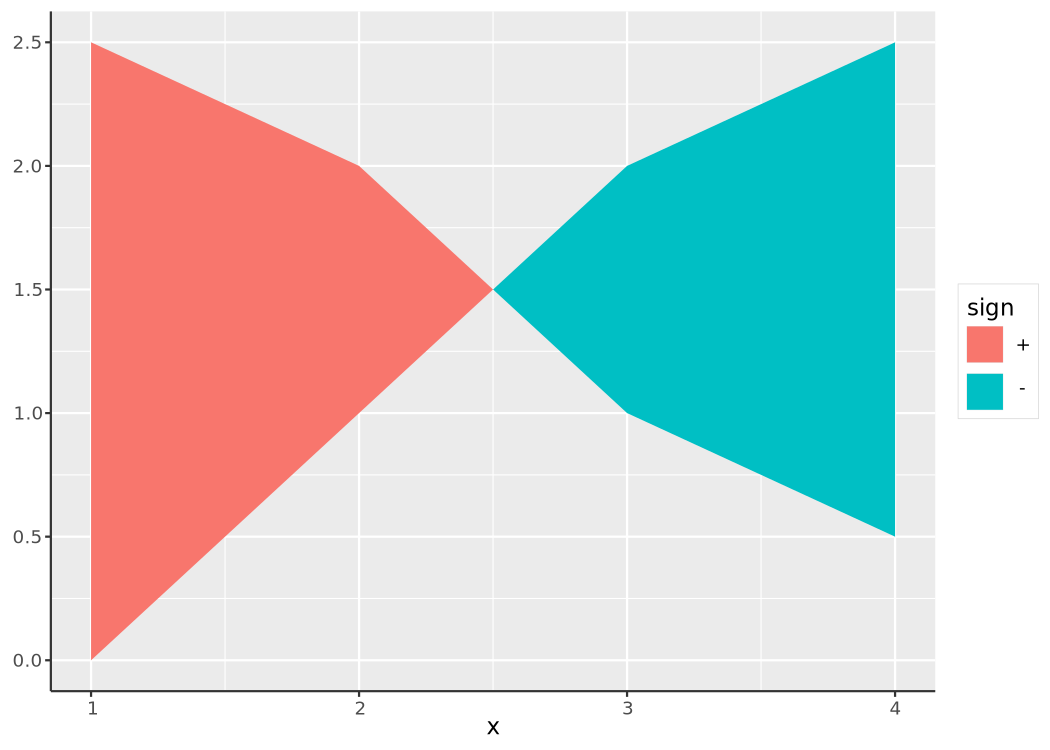

In [10]:
ggplot(dummy, aes(x="x", ymin="ymin", ymax="ymax")) + stat_difference()

## x/y summary functions — `stat_funxy` / `stat_centroid` / `stat_midpoint`

Apply a function to the x- and y-positions per group. `range(x)` x `mean(y)` makes range indicators:

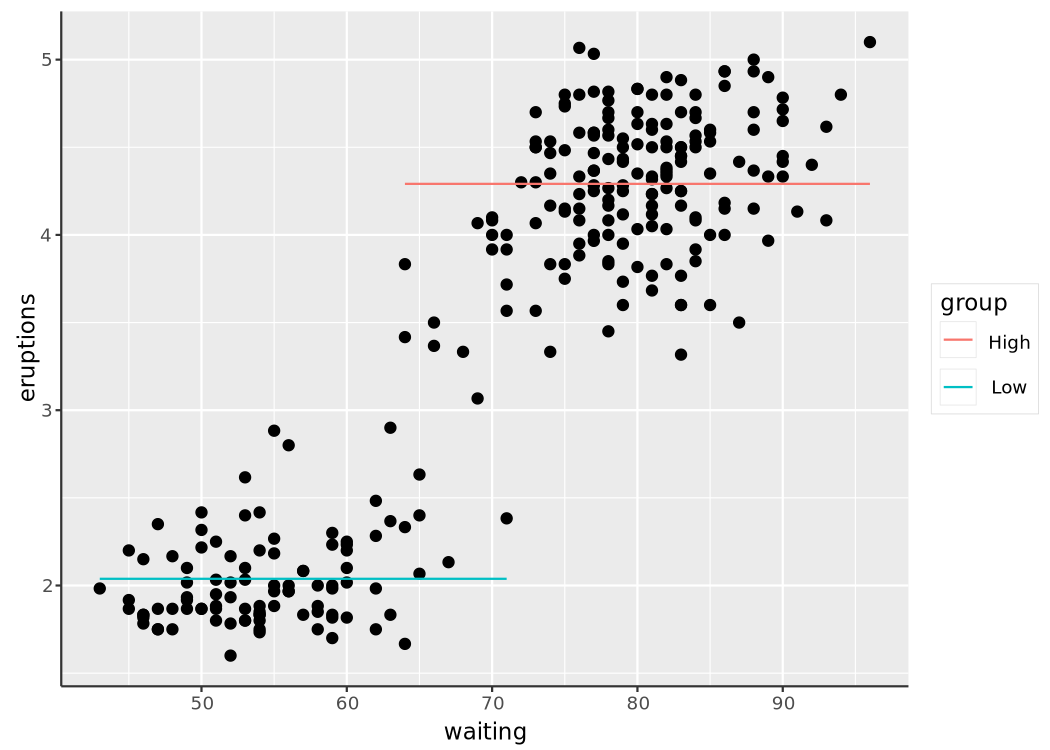

In [11]:
ggplot(faithful, aes(x="waiting", y="eruptions", group="group")) + geom_point() + stat_funxy(aes(color="group"), funx=lambda v: [float(np.min(v)), float(np.max(v))], funy=np.mean, geom="line")

`stat_centroid` (mean x, mean y) and `stat_midpoint` (mean of range) label groups:

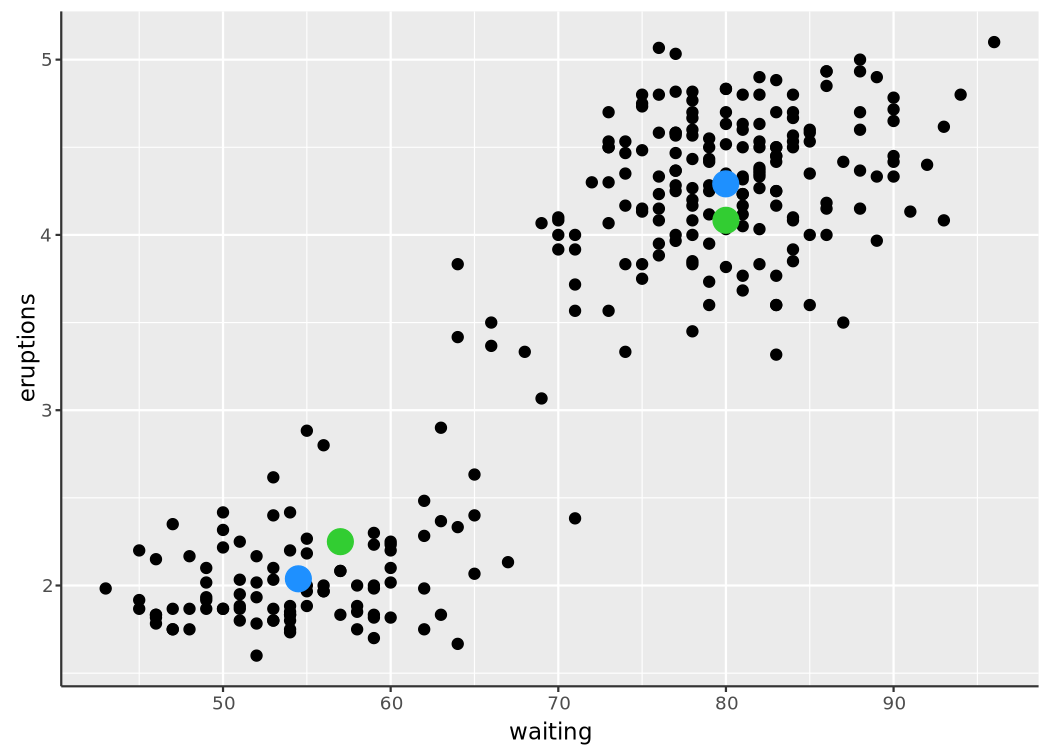

In [12]:
ggplot(faithful, aes(x="waiting", y="eruptions", group="group")) + geom_point() + stat_centroid(geom="point", color="dodgerblue", size=4) + stat_midpoint(geom="point", color="limegreen", size=4)

## Run-length encoding — `stat_rle`

Draws rectangles over runs where a series keeps the same value. Here `y = cos(x)` is binned into 3 levels:

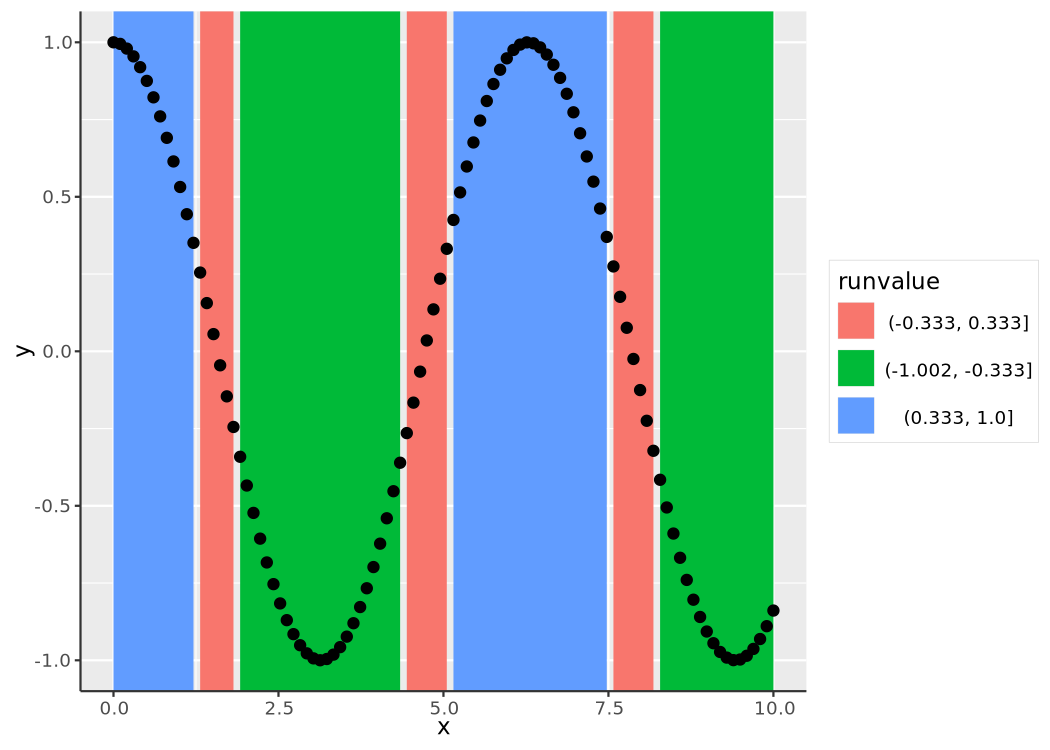

In [13]:
ggplot(rdf, aes(x="x", y="y")) + stat_rle(aes(label="lab")) + geom_point()

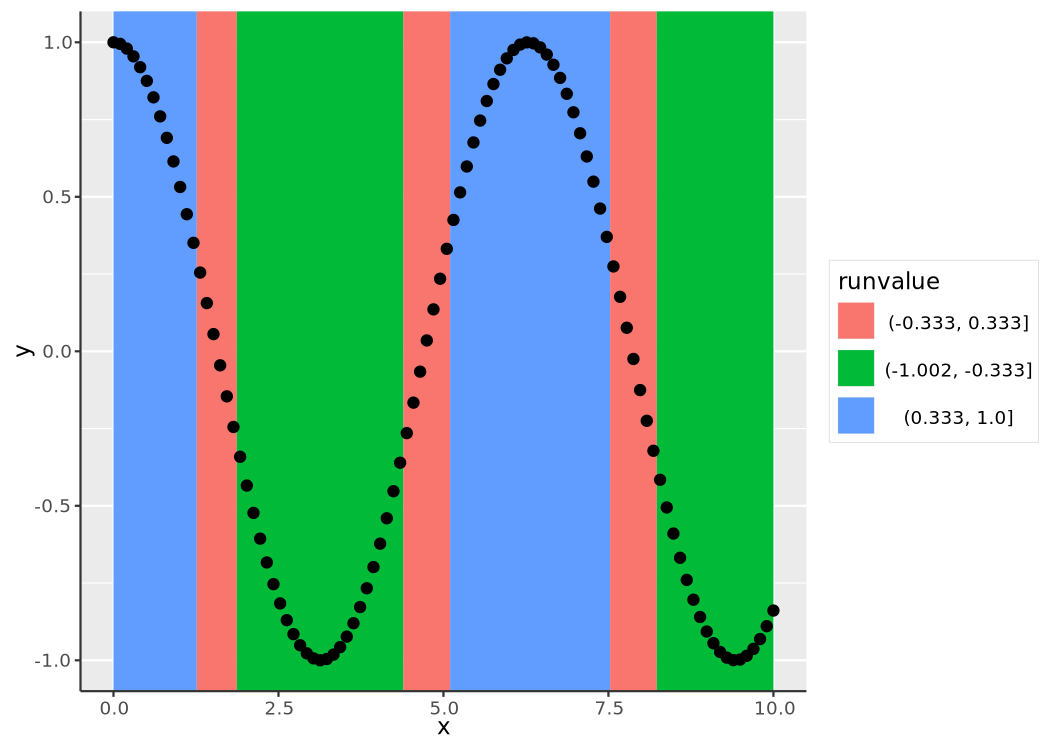

In [14]:
# Closing gaps between runs with align="center"
ggplot(rdf, aes(x="x", y="y")) + stat_rle(aes(label="lab"), align="center") + geom_point()